# Week1-1: Evaluating the likelihood on a grid
- Calculate the log(likelihood) for each pair of model parameters (mean(vr), dispersion(vr)) 
- Visualize the log(likelihood) on the 2D grid of (mean, dispersion) 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data_path = '../data/'

In [275]:
df = pd.read_csv(data_path+'Cas3_dg.csv')
df1 = pd.read_csv(data_path+'Cas3_dg_s1.csv')

df2 = df.sample(n=1)
print (df2['vr'])


125   -367.92
Name: vr, dtype: float64


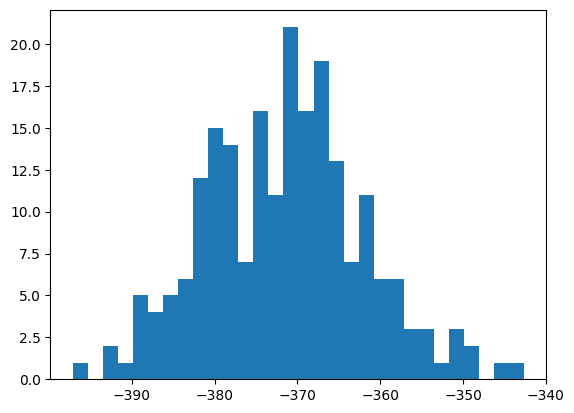

In [9]:
# Check the histogram of velocities of Cas3, we can estimate the range of mean (from -380 km/s to -360 km/s) and diserpsion (from 7 km/s to 12 km/s) by eye.
plt.figure()
plt.hist(df['vr'], bins=30);

In [361]:
# Now let's create a grid of 50x50 points in the range of -380 to -360 for mvr and 7 to 12 for dvr

mvr_grid = np.array(np.arange(-380, -360, .4))
dvr_grid = np.array(np.arange(5, 15, 0.1))

mvr_grid1 = np.array(np.arange(-420, -360, .4))
dvr_grid1 = np.array(np.arange(5, 20, 0.1))

mvr_grid2 = np.array(np.arange(-400, -330, .4))
dvr_grid2 = np.array(np.arange(1., 80, .2))

logL_grid = np.zeros((len(mvr_grid), len(dvr_grid)))
logL_grid1 = np.zeros((len(mvr_grid1), len(dvr_grid1)))
logL_grid2 = np.zeros((len(mvr_grid2), len(dvr_grid2)))


In [362]:
# for each pair of (mean(vr), dispersion(vr)), we define the following function to calculate the log(L) for all the stars in the dwarf galaxy Cas III
def log_Likelihood(mvr, dvr, vr_dg):
    
    logL = np.sum(np.log(1/(dvr * np.sqrt(2 * np.pi))) - ((vr_dg - mvr)**2) / (2 * dvr**2))

    return logL

In [363]:
# We now can calculate the log(L) for each gridding point
for i in range(logL_grid.shape[0]):
    for j in range(logL_grid.shape[1]):
        logL_grid[i, j] = log_Likelihood(mvr_grid[i], dvr_grid[j], df['vr'])

/Users/yuan/miniconda3/envs/pysme/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [364]:
# We now can calculate the log(L) for each gridding point
for i in range(logL_grid1.shape[0]):
    for j in range(logL_grid1.shape[1]):
        logL_grid1[i, j] = log_Likelihood(mvr_grid1[i], dvr_grid1[j], df1['vr'])

In [365]:
# We now can calculate the log(L) for each gridding point
for i in range(logL_grid2.shape[0]):
    for j in range(logL_grid2.shape[1]):
        logL_grid2[i, j] = log_Likelihood(mvr_grid2[i], dvr_grid2[j], np.asarray(df2['vr']))

/var/folders/sv/g85xms0x0cz4m76jsq8fh_wh0000gn/T/ipykernel_68797/1320733580.py:4: RuntimeWarning: overflow encountered in exp
  logL = np.sum(np.log(1.0/dvr * np.exp((vr_dg - mvr)**2) / (2 * dvr**2)))


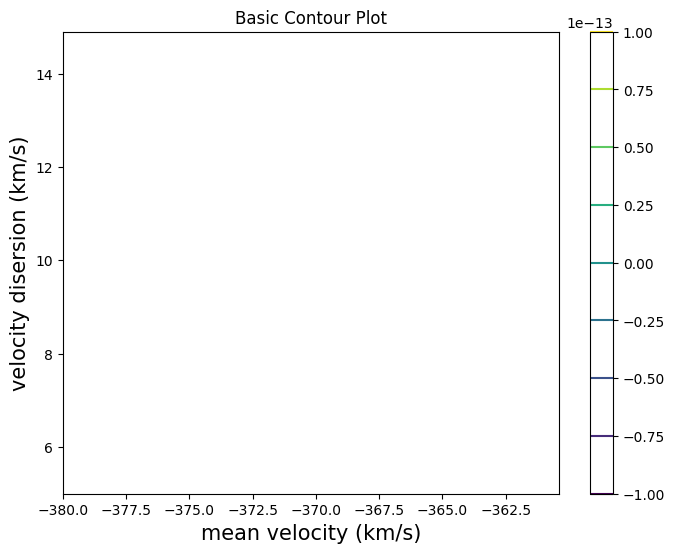

In [366]:
# Here comes to the visualizations!
# Note that when we plot in contour and imshow, the 2D array need to be inverted !!
# This is the contour plot of logL, whic does not make too much senses

plt.figure(figsize=(8, 6))
contour = plt.contour(mvr_grid, dvr_grid, logL_grid.T)
plt.colorbar(contour)  # Add colorbar




plt.title('Basic Contour Plot')
plt.xlabel('mean velocity (km/s)', fontsize=15)
plt.ylabel('velocity disersion (km/s)', fontsize=15)
plt.show()

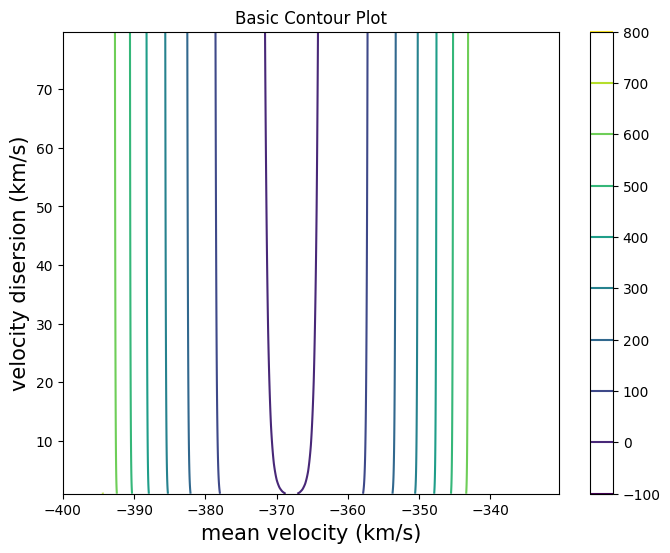

In [367]:



plt.figure(figsize=(8, 6))
contour = plt.contour(mvr_grid2, dvr_grid2, logL_grid2.T)
plt.colorbar(contour)  # Add colorbar
plt.title('Basic Contour Plot')
plt.xlabel('mean velocity (km/s)', fontsize=15)
plt.ylabel('velocity disersion (km/s)', fontsize=15)
plt.show()

In [368]:
print (len(df1))

21


/var/folders/sv/g85xms0x0cz4m76jsq8fh_wh0000gn/T/ipykernel_68797/1272497627.py:4: RuntimeWarning: invalid value encountered in subtract
  contour = plt.contour(mvr_grid, dvr_grid, np.exp(logL_grid.T-np.max(logL_grid)), levels=levels, cmap="Greens")
/var/folders/sv/g85xms0x0cz4m76jsq8fh_wh0000gn/T/ipykernel_68797/1272497627.py:5: RuntimeWarning: invalid value encountered in subtract
  contour = plt.contour(mvr_grid1, dvr_grid1, np.exp(logL_grid1.T-np.max(logL_grid1)), levels=levels, cmap="Blues")
/var/folders/sv/g85xms0x0cz4m76jsq8fh_wh0000gn/T/ipykernel_68797/1272497627.py:6: RuntimeWarning: invalid value encountered in subtract
  contour = plt.contour(mvr_grid2, dvr_grid2, np.exp(logL_grid2.T-np.max(logL_grid2)), levels=levels, cmap='Reds')


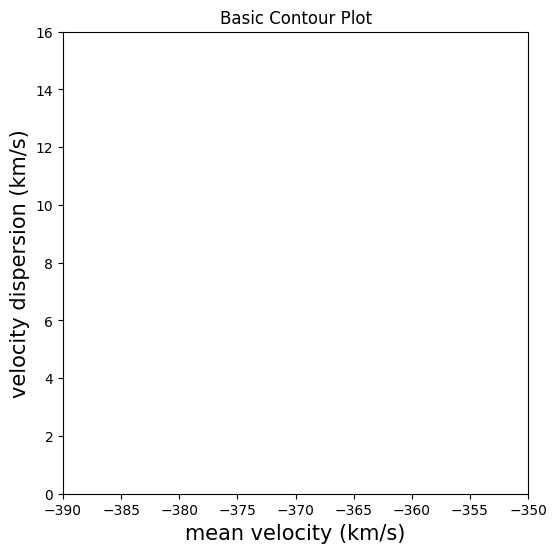

In [370]:
# This is the contour plot of Likelihood, we want it to be normalized to the maximum value
levels = np.array([0.16, 0.5, 0.84, 0.975])
plt.figure(figsize=(6,6))
contour = plt.contour(mvr_grid, dvr_grid, np.exp(logL_grid.T-np.max(logL_grid)), levels=levels, cmap="Greens")
contour = plt.contour(mvr_grid1, dvr_grid1, np.exp(logL_grid1.T-np.max(logL_grid1)), levels=levels, cmap="Blues")
contour = plt.contour(mvr_grid2, dvr_grid2, np.exp(logL_grid2.T-np.max(logL_grid2)), levels=levels, cmap='Reds')


# cbar = plt.colorbar(contour)  # Add colorbar

plt.ylim(0, 16)
plt.xlim(-390, -350)

plt.title('Basic Contour Plot')
plt.xlabel('mean velocity (km/s)', fontsize=15)
plt.ylabel('velocity dispersion (km/s)', fontsize=15)
plt.show()

/var/folders/sv/g85xms0x0cz4m76jsq8fh_wh0000gn/T/ipykernel_68797/2922373254.py:6: RuntimeWarning: invalid value encountered in subtract
  contour = plt.contour(mvr_grid2, dvr_grid2, np.exp(logL_grid2.T-np.max(logL_grid2)), levels=levels, cmap='Reds')


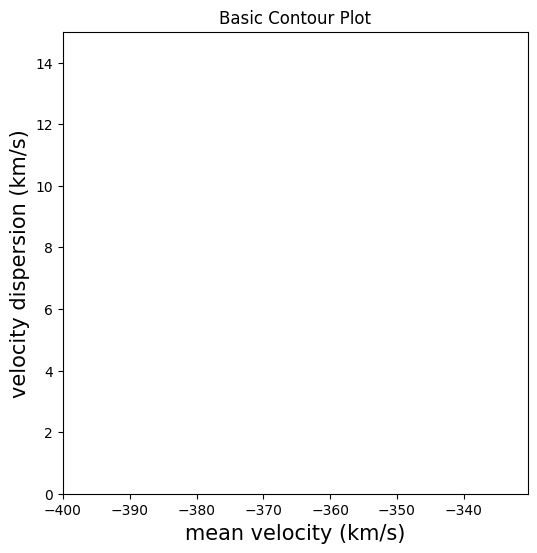

In [359]:
# This is the contour plot of Likelihood, we want it to be normalized to the maximum value
levels = np.array([0.16, 0.5, 0.84, 0.975])
plt.figure(figsize=(6,6))
# contour = plt.contour(mvr_grid, dvr_grid, np.exp(logL_grid.T-np.max(logL_grid)), levels=levels, cmap="Reds")
# contour = plt.contour(mvr_grid1, dvr_grid1, np.exp(logL_grid1.T-np.max(logL_grid1)), levels=levels, cmap="Blues")
contour = plt.contour(mvr_grid2, dvr_grid2, np.exp(logL_grid2.T-np.max(logL_grid2)), levels=levels, cmap='Reds')


# cbar = plt.colorbar(contour)  # Add colorbar
plt.ylim(0, 15)
# plt.xlim(-390, -360)
plt.title('Basic Contour Plot')
plt.xlabel('mean velocity (km/s)', fontsize=15)
plt.ylabel('velocity dispersion (km/s)', fontsize=15)
plt.show()

In [283]:
print (log_Likelihood(-370, 0.2, df2['vr']))
print (log_Likelihood(-370, 14, df2['vr']))

-52.47056208756506
-2.650094064309136


In [304]:
df2

,ra,dec,xki,eta,radius,signal,noise,vr,e_vr,P(member)
125,9.018791,51.563499,0.794,0.227,0.914,205.5,39.6,-367.92,5.26,1.0


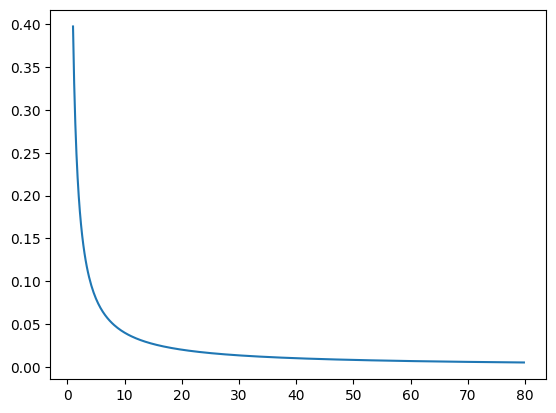

In [355]:
mvr = -368
dvr = np.array(np.arange(1., 80, .2))
loglike = np.empty(len(dvr))

for i in range(len(dvr)):
    loglike[i] = 1.0/(np.sqrt(2*np.pi)*dvr[i]) * np.exp(-0.5*((-367.92 - mvr)/ dvr[i])**2)
plt.figure()
plt.plot(dvr, loglike)

In [331]:

mvr_grid2 = np.array(np.arange(-400, -330, .4))
dvr_grid2 = np.array(np.arange(1., 80, .2))
L_grid2 = np.zeros((len(mvr_grid2), len(dvr_grid2)))


# We now can calculate the log(L) for each gridding point
for i in range(logL_grid2.shape[0]):
    for j in range(logL_grid2.shape[1]):
        # logL_grid2[i, j] = log_Likelihood(mvr_grid2[i], dvr_grid2[j], np.asarray(df2['vr']))
        L_grid2[i, j] = np.log(1.0/(np.sqrt(2*np.pi)*dvr_grid2[j]) * np.exp((-367.92 - mvr_grid2[i])**2) / (2 * dvr_grid2[j]**2))



/var/folders/sv/g85xms0x0cz4m76jsq8fh_wh0000gn/T/ipykernel_68797/3279225895.py:10: RuntimeWarning: overflow encountered in exp
  L_grid2[i, j] = np.log(1.0/(np.sqrt(2*np.pi)*dvr_grid2[j]) * np.exp((-367.92 - mvr_grid2[i])**2) / (2 * dvr_grid2[j]**2))


In [332]:
print (L_grid2)

[[inf inf inf ... inf inf inf]
 [inf inf inf ... inf inf inf]
 [inf inf inf ... inf inf inf]
 ...
 [inf inf inf ... inf inf inf]
 [inf inf inf ... inf inf inf]
 [inf inf inf ... inf inf inf]]
